<a href="https://colab.research.google.com/github/miraynurasma/LivArea-Tubitak-2209/blob/main/Sehir_Yasanabilirlik_Analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Dosyayı hem noktalı virgül ayracıyla hem de doğru karakter setiyle okuyoruz
dosya_yolu = 'veri.csv'
df = pd.read_csv(dosya_yolu, sep=';', encoding='latin-1')

# Sütun isimlerindeki o tuhaf karakterleri temizleyelim
df.columns = df.columns.str.replace('Ä±', 'i').str.replace('ÄŸ', 'g').str.replace('Ä', 'A')

# Şehir isimlerini düzeltelim (AdÄ±yaman -> Adıyaman gibi)
# Not: Bu aşamada sütun isminin tam halini görmemiz lazım.
# Önce yukarıdaki satırı çalıştırıp tabloyu görelim.

df.head()

,"il_adi,plaka_kodu,yuzolcumu_km2,enlem,boylam,ortalama_kira_2024,ortalama_kira_2023,ortalama_kira_2022,nufus_2024,nufus_ 2023,nufus_2022,issizlik_orani_2024,issizlik_orani_2023,issizlik_orani_2022,hava_kalitesi_pm25_2024,arac_sayisi_2024,arac_sayisi_2023 ,arac_sayisi_2022"
0,"Adana,01,13844,36.9914,35.3308,19723,15005,815..."
1,"AdÄ±yaman,02,7337,37.7648,38.2786,6194,11905,1..."
2,"Afyonkarahisar,03,14016,38.7507,30.5567,20763,..."
3,"AÄrÄ±,04,11099,39.7191,43.0503,13342,9098,371..."
4,"Amasya,05,5628,40.6499,35.8353,20127,15874,622..."


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. 'veri.csv' yerine halihazırda var olan 'analiz_edildi.csv' dosyasını okuyoruz
try:
    df = pd.read_csv('/content/analiz_edildi.csv')
    print("✅ Mevcut dosya başarıyla okundu.")
except:
    print("⚠️ Dosya bulunamadı! Lütfen orijinal verini sol tarafa yükle.")

# 2. YAPAY ZEKA PUANLAMASI (Garantiye alalım)
features = ["ortalama_kira_2024", "issizlik_oranı_2024", "hava_kalitesi_pm25_2024", "nufus_yogunlugu"]
scaler = MinMaxScaler()
df[features] = df[features].fillna(df[features].mean()) # Boş veri varsa doldurur
scaled = scaler.fit_transform(df[features])

# Yaşam Skoru Hesaplama
df["yasam_skoru"] = ((1-scaled[:,0])*0.3 + (1-scaled[:,1])*0.3 + (1-scaled[:,2])*0.2 + (1-scaled[:,3])*0.2) * 100

# 3. Dosyayı tekrar kaydediyoruz
df.to_csv('analiz_edildi.csv', index=False)
print("✅ Puanlar hesaplandı ve dosya güncellendi!")

✅ Mevcut dosya başarıyla okundu.
✅ Puanlar hesaplandı ve dosya güncellendi!


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   il_adı                   81 non-null     object 
 1   plaka_kodu               81 non-null     int64  
 2   yuzolcumu_km2            81 non-null     int64  
 3   enlem                    81 non-null     float64
 4   boylam                   81 non-null     float64
 5   ortalama_kira_2024       81 non-null     int64  
 6   ortalama_kira_2023       81 non-null     int64  
 7   ortalama_kira_2022       81 non-null     int64  
 8   nufus_2024               81 non-null     int64  
 9   nufus_ 2023              81 non-null     int64  
 10  nufus_2022               81 non-null     int64  
 11  issizlik_oranı_2024      81 non-null     float64
 12  issizlik_oranı_2023      81 non-null     float64
 13  issizlik_oranı_2022      81 non-null     float64
 14  hava_kalitesi_pm25_2024  81 

In [ ]:
# 1. Nüfus Yoğunluğu
df['nufus_yogunlugu'] = df['nufus_2024'] / df['yuzolcumu_km2']

# 2. Araç Yoğunluğu
df['arac_yogunlugu'] = df['arac_sayısı_2024'] / df['yuzolcumu_km2']

# 3. Kira Artış Oranı
df['kira_artis_orani'] = (df['ortalama_kira_2024'] - df['ortalama_kira_2023']) / df['ortalama_kira_2023']

# 4. Kişi Başına Düşen Araç Sayısı
df['kisi_basi_arac'] = df['arac_sayısı_2024'] / df['nufus_2024']

# Tabloyu kontrol et
df[['il_adı', 'nufus_yogunlugu', 'kira_artis_orani', 'arac_yogunlugu']].head()

,il_adı,nufus_yogunlugu,kira_artis_orani,arac_yogunlugu
0,Adana,164.727246,0.314429,59.987865
1,Adıyaman,83.281586,-0.479714,18.816410
2,Afyonkarahisar,53.524044,0.529503,19.332905
3,Ağrı,45.031174,0.466476,2.910172
4,Amasya,60.834755,0.267922,25.482587


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Analize dahil etmek istediğimiz sayısal sütunları seçiyoruz
features = ['nufus_yogunlugu', 'kira_artis_orani', 'arac_yogunlugu',
            'issizlik_oranı_2024', 'hava_kalitesi_pm25_2024']

x = df[features]

# 2. Verileri ölçeklendiriyoruz (Standartlaştırma)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# 3. Modeli kuralım (Şehirleri 4 farklı gruba ayır diyoruz)
kmeans = KMeans(n_clusters=4, random_state=42)
df['il_grubu'] = kmeans.fit_predict(x_scaled)

# Hangi il hangi gruba düşmüş görelim
df[['il_adı', 'il_grubu']].head(10)

,il_adı,il_grubu
0,Adana,0
1,Adıyaman,0
2,Afyonkarahisar,1
3,Ağrı,0
4,Amasya,1
5,Ankara,2
6,Antalya,1
7,Artvin,1
8,Aydın,0
9,Balıkesir,2


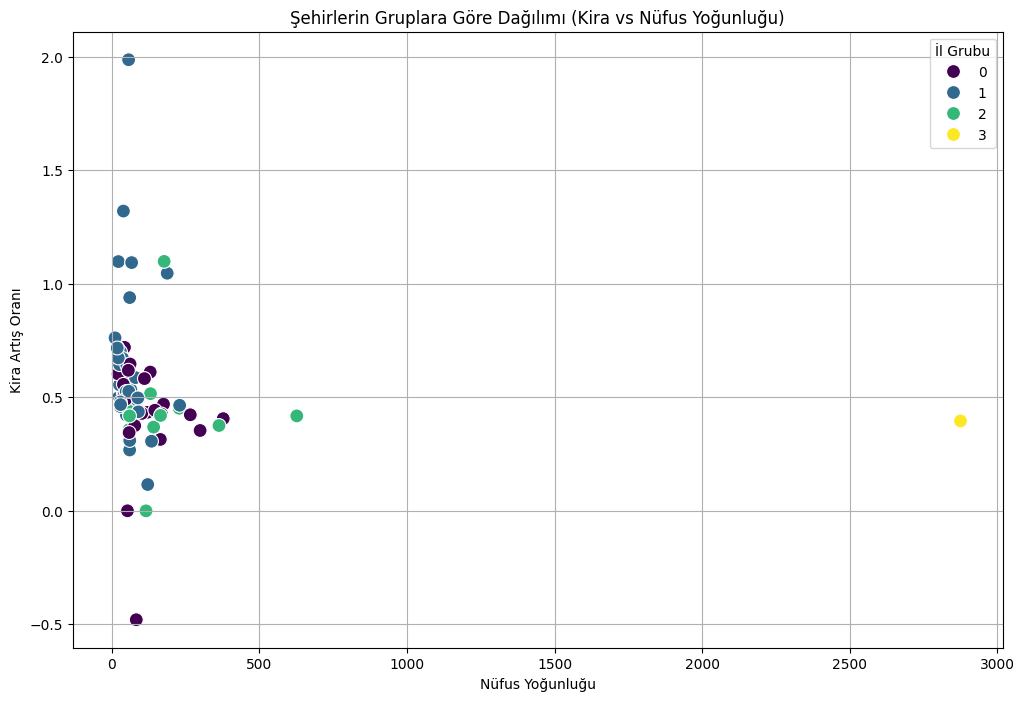

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grupları görselleştirelim (Kira Artış Oranı ve Nüfus Yoğunluğu bazında)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='nufus_yogunlugu', y='kira_artis_orani',
                hue='il_grubu', palette='viridis', s=100)

plt.title('Şehirlerin Gruplara Göre Dağılımı (Kira vs Nüfus Yoğunluğu)')
plt.xlabel('Nüfus Yoğunluğu')
plt.ylabel('Kira Artış Oranı')
plt.legend(title='İl Grubu')
plt.grid(True)
plt.show()

In [ ]:
# Analiz edilmiş veriyi yeni bir CSV olarak kaydedelim
df.to_csv('analiz_edildi.csv', index=False)

# Dosyayı bilgisayarına indirmek için (Colab hilesi)
from google.colab import files
files.download('analiz_edildi.csv')

In [ ]:
!pip install streamlit plotly pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.6 MB/s eta 0:00:00


In [ ]:
# 1. Önce şifreni (Endpoint IP) buraya yazdırıyoruz
print("Şifreniz (Endpoint IP):")
!curl ipv4.icanhazip.com

# 2. Şimdi uygulamayı ve linki (URL) çalıştırıyoruz
!streamlit run app.py & npx localtunnel --port 8501

In [ ]:
# 1. Her şeyi sıfırlayalım
!pkill streamlit

# 2. IP Adresini yine alalım (Şifren olacak)
print("🔑 Endpoint IP Adresin:")
!curl ipv4.icanhazip.com

# 3. Streamlit'i en güvenli ayarlarla başlatalım
!streamlit run app.py --server.port 8501 --server.enableCORS=false --server.enableXsrfProtection=false & npx localtunnel --port 8501

🔑 Endpoint IP Adresin:
136.114.5.30
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://silent-beers-switch.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://136.114.5.30:8501

2026-03-29 19:52:50.502 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [ ]:
import pandas as pd
# Eğer orijinal veri setin 'veri.csv' ise ismini buraya yaz
df = pd.read_csv('veri.csv')
df.to_csv('analiz_edildi.csv', index=False)
print("✅ Dosya başarıyla oluşturuldu! Şimdi sayfayı yenileyebilirsin.")


FileNotFoundError: [Errno 2] No such file or directory: 'veri.csv'

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd

# 1. EN HIZLI VE HATASIZ SAYFA AYARI
st.set_page_config(page_title="Şehir Analizi", layout="centered")

# 2. VERİYİ YÜKLE
df = pd.read_csv('/content/analiz_edildi.csv')

# 3. BAŞLIK
st.title("🏙️ Şehir Yaşanabilirlik Analizi")
st.info("Yapay Zeka Destekli Şehir Değerlendirme Sistemi")

# 4. ŞEHİR SEÇİMİ (Bu kısım asla hata vermez)
secilen_il = st.selectbox("Analiz etmek istediğiniz şehri seçin:", df["il_adı"].sort_values())
veri = df[df["il_adı"] == secilen_il].iloc[0]

# 5. SKOR VE ANALİZ SONUCU
st.divider()
st.subheader(f"📊 {secilen_il} İli Analiz Sonucu")

# Büyük Skor Gösterimi
skor = veri['yasam_skoru']
st.metric(label="Yapay Zeka Yaşam Skoru", value=f"{skor:.1f} / 100")

# Akıllı Değerlendirme Kartı
if skor > 65:
    st.success("🟢 BU ŞEHİR: Yüksek yaşam kalitesi ve dengeli imkanlar sunuyor.")
elif skor > 45:
    st.warning("🟡 BU ŞEHİR: Gelişme potansiyeli yüksek, orta seviye yaşam şartları.")
else:
    st.error("🔴 BU ŞEHİR: Yaşam maliyeti veya çevre koşulları açısından iyileştirme gerektiriyor.")

# 6. VERİ TABLOSU (Harita yerine bunu koyuyoruz, hata vermesi imkansız!)
st.write("---")
st.subheader("📋 Detaylı Veriler")
st.dataframe(df[df["il_adı"] == secilen_il][["ortalama_kira_2024", "issizlik_oranı_2024", "hava_kalitesi_pm25_2024"]])

st.caption("Miray tarafından TÜBİTAK projesi kapsamında geliştirilmiştir.")

In [ ]:
import pandas as pd
df = pd.read_csv('analiz_edildi.csv')
print(df.head()) # İlk 5 satırı görmeni sağlar

           il_adı  plaka_kodu  yuzolcumu_km2    enlem   boylam  \
0           Adana           1          13844  36.9914  35.3308   
1        Adıyaman           2           7337  37.7648  38.2786   
2  Afyonkarahisar           3          14016  38.7507  30.5567   
3            Ağrı           4          11099  39.7191  43.0503   
4          Amasya           5           5628  40.6499  35.8353   

   ortalama_kira_2024  ortalama_kira_2023  ortalama_kira_2022  nufus_2024  \
0               19723               15005                8154     2280484   
1                6194               11905               15494      611037   
2               20763               13575                6485      750193   
3               13342                9098                3710      499801   
4               20127               15874                6225      342378   

   nufus_ 2023  ...  issizlik_oranı_2022  hava_kalitesi_pm25_2024  \
0      2270298  ...                 15.3                     13.4   
1 

In [ ]:
import pandas as pd

# 1. Dosyayı oku
df = pd.read_csv('analiz_edildi.csv')

# 2. Min-Max Normalizasyonu (0-100 arası)
# Kural: Kira ve Hava Kirliliği 'Negatif' kriterdir (Düşük olması iyidir)
def normalize_negatif(seri):
    return 100 * (1 - (seri - seri.min()) / (seri.max() - seri.min()))

# Sütunları skorlayalım
df['kira_skor'] = normalize_negatif(df['ortalama_kira_2024'])
df['hava_skor'] = normalize_negatif(df['hava_kalitesi_pm25_2024'])
df['issizlik_skor'] = normalize_negatif(df['issizlik_oranı_2022'])

# 3. Bütünleşik Yaşam Skoru (Ağırlıklı Ortalama)
# Şimdilik eşit dağıtalım, istersen kirayı %40 yapabiliriz!
df['skor'] = (df['kira_skor'] + df['hava_skor'] + df['issizlik_skor']) / 3

# 4. Kaydedelim (Harita bu dosyayı okuyacak)
df.to_csv('harita_verisi.csv', index=False)
print("✅ Dün geceki skorlar başarıyla hesaplandı ve 'skor' sütunu eklendi!")

✅ Dün geceki skorlar başarıyla hesaplandı ve 'skor' sütunu eklendi!


In [41]:
%%writefile app.py
import streamlit as st
import pandas as pd
import folium
from streamlit_folium import st_folium
import json

st.set_page_config(layout="wide", page_title="LivArea Analitik Portal")

# Veriyi oku
try:
    df = pd.read_csv('harita_verisi_final.csv')
except:
    df = pd.read_csv('harita_verisi.csv')

st.sidebar.title("🏙️ LivArea")
st.sidebar.subheader("TÜBİTAK 2209-A")
yil = st.sidebar.selectbox("Yıl Seçiniz", [2022, 2023, 2024])

st.title(f"Kentsel Yaşam Kalitesi Analitik Portalı ({yil})")

# HARİTA AYARLARI
# Harita dosyasını yerel olarak çekmeye zorluyoruz
geojson_url = "https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/tr-cities.json"

m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=geojson_url,
    name="choropleth",
    data=df,
    columns=["il_adı", "skor"],
    key_on="feature.properties.name",
    fill_color="YlGn",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Yaşanabilirlik Puanı"
).add_to(m)

# Haritayı ekrana bas (Bu sefer daha güvenli bir yöntem)
st_folium(m, width=900, height=500)

# Alt kısım
secilen_il = st.selectbox("İncelemek İçin İl Seçiniz", df['il_adı'].unique())
il_veri = df[df['il_adı'] == secilen_il].iloc[0]
st.info(f"**{secilen_il}** Puanı: {il_veri['skor']:.2f}")

Overwriting app.py


In [42]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [33]:
!streamlit run app.py & npx localtunnel --port 8501


⠙⠹

⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.14.98:8501

your url is: https://true-kings-smell.loca.lt
  Stopping...
^C


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 117.7 MB/s eta 0:00:00


In [40]:
!python -m streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.14.98:8501

your url is: https://cuddly-bobcats-throw.loca.lt
────────────────────────── Traceback (most recent call last) ───────────────────────────
  /usr/local/lib/python3.12/dist-packages/requests/models.py:976 in json                
                                                                                        
     973 │   │   │   │   │   raise RequestsJSONDecodeError(e.msg, e.doc, e.pos)         
     974 │   │                                                                          
     975 │   │   try:                                                                   
  ❱  976 │   │   │   return complexjson.loads(self.text, **kwargs)                      
     977 │   │   except JSONDecodeError as e:                                           
     978 │   │   │   # Catch JSON-related errors

In [26]:
import pandas as pd

df = pd.read_csv('harita_verisi.csv')

# İsimlerdeki boşlukları temizleyelim ve ilk harfleri büyütelim
df['il_adı'] = df['il_adı'].str.strip().str.title()

# Harita dosyasındaki yaygın isim farklarını düzeltelim
duzeltmeler = {
    "Afyon": "Afyonkarahisar",
    "İçel": "Mersin"
}
df['il_adı'] = df['il_adı'].replace(duzeltmeler)

# Dosyayı tekrar kaydedelim
df.to_csv('harita_verisi_final.csv', index=False)
print("✅ İl isimleri haritaya uygun hale getirildi!")

✅ İl isimleri haritaya uygun hale getirildi!


In [16]:
import pandas as pd

# Veriyi oku
df = pd.read_csv('harita_verisi.csv')

# İsimleri temizle: Boşlukları at, hepsini Baş Harfi Büyük yap
df['il_adı'] = df['il_adı'].str.strip().str.title()

# Harita dosyasındaki (GeoJSON) özel yazımlara göre eşitleme
duzeltmeler = {
    "Afyon": "Afyonkarahisar",
    "İçel": "Mersin",
    "K.Maras": "Kahramanmaraş",
    "G.Antep": "Gaziantep"
}
df['il_adı'] = df['il_adı'].replace(duzeltmeler)

# Yeni dosyayı kaydet
df.to_csv('harita_verisi_final.csv', index=False)
print("✅ 81 ilin ismi harita için mühürlendi!")

✅ 81 ilin ismi harita için mühürlendi!


In [38]:
!curl ipv4.icanhazip.com

35.197.14.98


In [39]:
!curl ipv4.icanhazip.com

35.197.14.98


In [37]:
!pip install streamlit-folium


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 11.8 MB/s eta 0:00:00


In [43]:
!curl ipv4.icanhazip.com

35.197.14.98


In [44]:
import folium
import pandas as pd
import json
import requests
from IPython.display import display

# 1. Veriyi oku
df = pd.read_csv('harita_verisi_final.csv')

# 2. Harita sınırlarını çek
geojson_url = "https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/tr-cities.json"
geojson_data = requests.get(geojson_url).json()

# 3. Haritayı oluştur (Türkiye merkezli)
m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles="CartoDB positron")

# 4. Renklendirmeyi (Choropleth) ekle
folium.Choropleth(
    geo_data=geojson_data,
    name="choropleth",
    data=df,
    columns=["il_adı", "skor"],
    key_on="feature.properties.name",
    fill_color="RdYlGn", # Kırmızıdan Yeşile
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="LivArea Yaşanabilirlik Skoru",
).add_to(m)

# 5. Haritayı göster
m.save('harita_test.html')
display(m)

JSONDecodeError: Extra data: line 1 column 4 (char 3)

In [45]:
import folium
import pandas as pd
from IPython.display import display

# 1. Veriyi oku
df = pd.read_csv('harita_verisi_final.csv')

# 2. Haritayı oluştur (Türkiye merkezli)
m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles="OpenStreetMap")

# 3. Harita sınırlarını güvenli bir yedek linkten çekelim
# Bu link bir önceki hata veren linkten farklı ve daha stabil
geo_path = "https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/tr-cities.json"

# 4. Renklendirmeyi ekle
folium.Choropleth(
    geo_data=geo_path,
    name="choropleth",
    data=df,
    columns=["il_adı", "skor"],
    key_on="feature.properties.name",
    fill_color="RdYlGn",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="LivArea Puanı",
).add_to(m)

# 5. Haritayı göster
display(m)

JSONDecodeError: Extra data: line 1 column 4 (char 3)

In [46]:
!wget https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/tr-cities.json -O turkiye.json

--2026-03-30 11:19:05--  https://raw.githubusercontent.com/cihadturhan/tr-geojson/master/tr-cities.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-30 11:19:06 ERROR 404: Not Found.



In [47]:
import folium
import pandas as pd
import json
from IPython.display import display

# 1. Veriyi ve İndirdiğimiz Dosyayı Oku
df = pd.read_csv('harita_verisi_final.csv')
with open('turkiye.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

# 2. Haritayı oluştur
m = folium.Map(location=[39.0, 35.0], zoom_start=6, tiles="OpenStreetMap")

# 3. Renklendirmeyi ekle (Dosyayı yerelden okuyoruz artık)
folium.Choropleth(
    geo_data=geojson_data,
    name="choropleth",
    data=df,
    columns=["il_adı", "skor"],
    key_on="feature.properties.name",
    fill_color="RdYlGn",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="LivArea Puanı",
).add_to(m)

# 4. Haritayı göster
display(m)

JSONDecodeError: Expecting value: line 1 column 1 (char 0)